# Demo 1 — MCP

**Scenario:** ask an LLM about a stock. The LLM has two tool servers.

```
   you (this notebook)
        │
        ▼
   Claude (LLM)  ◄── MCP client (mcp_helpers.py)
        │
        ├──► stock_mcp_server.py    (subprocess via stdio)
        │      get_quote, get_history, get_company_info, get_news_headlines
        │
        └──► viz_mcp_server.py      (subprocess via stdio)
               line_chart, compare_lines
```

| File | Tools |
|------|-------|
| [`../shared/stock_mcp_server.py`](../shared/stock_mcp_server.py) | `get_quote`, `get_history`, `get_company_info`, `get_news_headlines` |
| [`viz_mcp_server.py`](viz_mcp_server.py) | `line_chart`, `compare_lines` |

Data backend: `yfinance` (no API key required). For production, swap to a company-maintained MCP server such as [Alpha Vantage's official one](https://mcp.alphavantage.co/).

## First-time setup

Run this once in a terminal, from the directory where you want the repo:

```bash
git clone https://github.com/jackwu502/ivado-protocol.git
cd ivado-protocol

python3.12 -m venv .venv
source .venv/bin/activate

python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name ivado-lab --display-name "ivado-lab (3.12)"
```

Create your local `.env` file:

```bash
cp .env.example .env
```

Then edit `.env` and fill in one credential route:

```bash
# Option 1: Anthropic direct
ANTHROPIC_API_KEY=sk-ant-...
ANTHROPIC_MODEL=claude-sonnet-4-6

# Option 2: OpenRouter-compatible Anthropic endpoint
# ANTHROPIC_BASE_URL=https://openrouter.ai/api
# ANTHROPIC_API_KEY=sk-or-v1-...
# ANTHROPIC_MODEL=anthropic/claude-sonnet-4.5
```

Do not commit `.env`; it is intentionally gitignored.

Start Jupyter from the repo root and select the `ivado-lab (3.12)` kernel:

```bash
python -m jupyter lab
```


In [1]:
# ── Bootstrap: resolve paths to shared/ and sibling helpers ──
import sys
from pathlib import Path
HERE = Path.cwd()
ROOT = HERE.parent
sys.path.insert(0, str(ROOT))   # so `from shared.X import Y` works
sys.path.insert(0, str(HERE))   # so sibling helpers import directly
STOCK_MCP_SERVER = str(ROOT / "shared" / "stock_mcp_server.py")
VIZ_MCP_SERVER = str(HERE / "viz_mcp_server.py")


In [2]:
%pip install -q mcp anthropic yfinance matplotlib python-dotenv

import os
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

if not os.getenv("ANTHROPIC_API_KEY"):
    print("Note: ANTHROPIC_API_KEY not set in .env — the final 'hand to Claude' cell will skip.")
else:
    print(f"ready  (model={os.getenv('ANTHROPIC_MODEL', 'claude-sonnet-4-6')})")

Note: you may need to restart the kernel to use updated packages.
ready  (model=anthropic/claude-sonnet-4.5)


## What an MCP server actually looks like

Below is the full source of `shared/stock_mcp_server.py`. Notice three things:

1. `FastMCP("stock-server")` — one line creates the server.
2. Each `@mcp.tool()` decorator turns a Python function into an MCP tool.
3. The function's **type hints + docstring** become the schema the LLM sees — no separate JSON schema written by hand.

In [3]:
from IPython.display import Code
Code(filename=str(ROOT / "shared" / "stock_mcp_server.py"), language="python")

"""A minimal MCP server exposing stock-market tools backed by yfinance.

Run directly:  python stock_mcp_server.py
This server speaks the Model Context Protocol over stdio.

In production you would point to a company-maintained MCP server such as
Alpha Vantage's official one (https://mcp.alphavantage.co/). yfinance is
used here so the lab runs without any API key.
"""

from __future__ import annotations

from datetime import datetime, timedelta

import yfinance as yf
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("stock-server")


@mcp.tool()
def get_quote(ticker: str) -> dict:
    """Get the latest quote for a ticker (price, change, volume).

    Example: get_quote("NVDA")
    """
    t = yf.Ticker(ticker)
    info = t.fast_info
    hist = t.history(period="2d")
    if hist.empty:
        return {"error": f"no data for {ticker}"}
    last = hist.iloc[-1]
    prev = hist.iloc[-2] if len(hist) >= 2 else last
    change = float(last["Close"] - prev["Close"])
    pct = float((change / prev["Close"]) * 100) if prev["Close"] else 0.0
    return {
        "ticker": ticker.upper(),
        "price": float(last["Close"]),
        "change": change,
        "change_pct": pct,
        "volume": int(last["Volume"]),
        "currency": getattr(info, "currency", "USD"),
        "timestamp": str(hist.index[-1].date()),
    }


@mcp.tool()
def get_history(ticker: str, days: int = 30) -> dict:
    """Get daily closing prices for the last N days.

    Example: get_history("NVDA", days=7)
    """
    end = datetime.utcnow().date()
    start = end - timedelta(days=days * 2)  # buffer for weekends/holidays
    hist = yf.Ticker(ticker).history(start=start, end=end + timedelta(days=1))
    if hist.empty:
        return {"error": f"no data for {ticker}"}
    hist = hist.tail(days)
    return {
        "ticker": ticker.upper(),
        "dates": [str(d.date()) for d in hist.index],
        "closes": [float(x) for x in hist["Close"]],
        "highs": [float(x) for x in hist["High"]],
        "lows": [float(x) for x in hist["Low"]],
    }


@mcp.tool()
def get_company_info(ticker: str) -> dict:
    """Get company name, sector, industry, market cap.

    Example: get_company_info("NVDA")
    """
    info = yf.Ticker(ticker).info or {}
    return {
        "ticker": ticker.upper(),
        "name": info.get("longName") or info.get("shortName"),
        "sector": info.get("sector"),
        "industry": info.get("industry"),
        "market_cap": info.get("marketCap"),
        "summary": (info.get("longBusinessSummary") or "")[:500],
    }


@mcp.tool()
def get_news_headlines(ticker: str, limit: int = 5) -> dict:
    """Get recent news headlines for a ticker.

    Example: get_news_headlines("NVDA", limit=3)
    """
    items = yf.Ticker(ticker).news or []
    headlines = []
    for it in items[:limit]:
        # yfinance recently changed schema; tolerate both shapes
        content = it.get("content") or it
        headlines.append({
            "title": content.get("title") or it.get("title"),
            "publisher": (content.get("provider") or {}).get("displayName") or it.get("publisher"),
            "url": (content.get("canonicalUrl") or {}).get("url") or it.get("link"),
        })
    return {"ticker": ticker.upper(), "headlines": headlines}


if __name__ == "__main__":
    mcp.run(transport="stdio")

## List tools

Each server *advertises* its tools. **The servers themselves are passive — they cannot initiate anything; they only respond when called.** That is the MCP contract.

In [4]:
from mcp_helpers import list_tools

await list_tools(STOCK_MCP_SERVER)

[/Users/jackwu/Downloads/Python Projects/Python Projects/ivado-protocol/shared/stock_mcp_server.py]
  • get_quote(ticker)
      Get the latest quote for a ticker (price, change, volume).
  • get_history(ticker, days)
      Get daily closing prices for the last N days.
  • get_company_info(ticker)
      Get company name, sector, industry, market cap.
  • get_news_headlines(ticker, limit)
      Get recent news headlines for a ticker.


In [5]:
await list_tools(VIZ_MCP_SERVER)

[/Users/jackwu/Downloads/Python Projects/Python Projects/ivado-protocol/demo1_mcp/viz_mcp_server.py]
  • line_chart(dates, values, title, ylabel)
      Line chart of `values` indexed by `dates` (YYYY-MM-DD strings).
  • compare_lines(dates, series, title, ylabel)
      Compare multiple series on the same axes.


## Call one tool directly

In [6]:
from mcp_helpers import call_tool

await call_tool(STOCK_MCP_SERVER, "get_quote", ticker="NVDA")

{
  "ticker": "NVDA",
  "price": 198.4499969482422,
  "change": -1.1200103759765625,
  "change_pct": -0.5612117727474994,
  "volume": 128257500,
  "currency": "USD",
  "timestamp": "2026-05-01"
}


In [7]:
await call_tool(STOCK_MCP_SERVER, "get_history", ticker="NVDA", days=10)

{
  "ticker": "NVDA",
  "dates": [
    "2026-04-20",
    "2026-04-21",
    "2026-04-22",
    "2026-04-23",
    "2026-04-24",
    "2026-04-27",
    "2026-04-28",
    "2026-04-29",
    "2026-04-30",
    "2026-05-01"
  ],
  "closes": [
    202.05999755859375,
    199.8800048828125,
    202.5,
    199.63999938964844,
    208.27000427246094,
    216.61000061035156,
    213.1699981689453,
    209.25,
    199.57000732421875,
    198.4499969482422
  ],
  "highs": [
    202.1699981689453,
    202.75,
    202.5,
    203.8300018310547,
    210.9499969482422,
    216.8300018310547,
    214.72999572753906,
    212.72000122070312,
    210.3000030517578,
    203.0
  ],
  "lows": [
    197.83999633789062,
    199.0,
    199.0,
    197.22000122070312,
    199.80999755859375,
    207.3800048828125,
    208.1999969482422,
    207.5800018310547,
    198.6999969482422,
    197.1199951171875
  ]
}


## Hand both servers to Claude

The LLM gets all six tools. **The output below shows the contract live:**

1. **`══ TOOL MENU SENT TO CLAUDE ══`** — exactly the schemas Claude receives (auto-generated from each function's signature + docstring)
2. **`← tool_use  name=...  input=...`** — the raw decision Claude returned. No `if tool_name == "..."` in our code; Claude picked from the menu by reading the descriptions.
3. **`→ calling ...`** — our dispatcher executes whichever tool Claude named.

This whole loop is what makes MCP "the LLM is the only orchestrator" concrete.

(model=anthropic/claude-sonnet-4.5, via OpenRouter)



══ TOOL MENU SENT TO CLAUDE ══
  (these schemas are auto-generated from each tool's signature + docstring)
  • get_quote(ticker:string) (required: ['ticker'])
      "Get the latest quote for a ticker (price, change, volume)."
  • get_history(ticker:string, days:integer) (required: ['ticker'])
      "Get daily closing prices for the last N days."
  • get_company_info(ticker:string) (required: ['ticker'])
      "Get company name, sector, industry, market cap."
  • get_news_headlines(ticker:string, limit:integer) (required: ['ticker'])
      "Get recent news headlines for a ticker."
  • line_chart(dates:array, values:array, title:string, ylabel:string) (required: ['dates', 'values'])
      "Line chart of `values` indexed by `dates` (YYYY-MM-DD strings)."
  • compare_lines(dates:array, series:object, title:string, ylabel:string) (required: ['dates', 'series'])
      "Compare multiple series on the same axes."
══ END MENU ══

YOU say:
  How has NVDA traded over the last 10 days? Plot the cl

[round 1] CLAUDE returned (stop_reason='tool_use'):
  ← text      "I'll get the last 10 days of trading data for NVDA and plot the closing prices for you."
  ← tool_use  name='get_history'  input={'ticker': 'NVDA', 'days': 10}
  (Claude picked these from the menu above — based on tool name + description)
  → calling get_history from /Users/jackwu/Downloads/Python Projects/Python Projects/ivado-protocol/shared/stock_mcp_server.py


     result (text): {   "ticker": "NVDA",   "dates": [     "2026-04-20",     "2026-04-21",     "2026-04-22",     "2026-04-23",     "2026-04-24",     "2026-04-27",     "2026-04-28",



[round 2] CLAUDE returned (stop_reason='tool_use'):
  ← text      'Now let me create a chart of these closing prices:'
  ← tool_use  name='line_chart'  input={'dates': ['2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01'], 'values': [202.06, 199.88, 202.5, 199.64, 208.27, 216.61, 213.17, 209.25, 199.57, 198.45], 'title': 'NVDA Closing Prices - Last 10 Days', 'ylabel': 'Price ($)'}
  (Claude picked these from the menu above — based on tool name + description)
  → calling line_chart from /Users/jackwu/Downloads/Python Projects/Python Projects/ivado-protocol/demo1_mcp/viz_mcp_server.py
     result (image): a image/png (shown below)


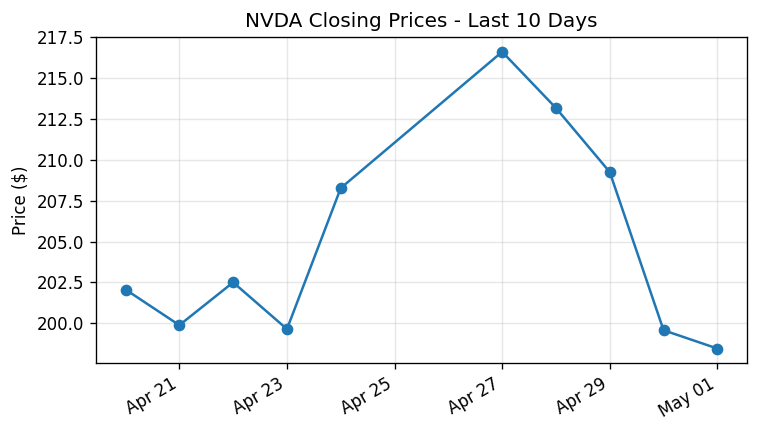


CLAUDE final answer:
  ## Analysis of NVDA's 10-Day Trading Pattern

Here's what I observe from the chart:

**Key Movements:**

1. **Initial Consolidation (Apr 20-23)**: NVDA traded relatively flat in the $199-$202 range, showing some consolidation with minor volatility.

2. **Strong Rally (Apr 24-27)**: The stock experienced a significant rally, jumping from around $199.64 on April 23rd to a peak of **$216.61 on April 27th** - a gain of approximately **8.5%** in just a few days. This was the highest point in the 10-day period.

3. **Sharp Reversal (Apr 28-May 1)**: After hitting the peak, NVDA reversed course and declined steadily over the next few days, ending at **$198.45 on May 1st** - giving back all the gains and actually closing slightly lower than where it started.

**Overall Pattern**: This shows a classic "spike and retreat" pattern, where the stock rallied sharply mid-period but couldn't sustain those levels. The net change over the 10-day period was slightly negative (down

In [8]:
from mcp_helpers import chat_with_claude

await chat_with_claude(
    message=(
        "How has NVDA traded over the last 10 days? "
        "Plot the closing prices and tell me what you see."
    ),
    servers=[STOCK_MCP_SERVER, VIZ_MCP_SERVER],
)

### What just happened — the MCP architecture in action

Look at the trace above:

- Every tool call **originated from Claude**.
- Every tool result **returned to Claude**.
- The two servers **never talked to each other** — they don't even know the other exists.

Claude was the only orchestrator. All the data — stock prices, the PNG — flowed through Claude's context window. That is the MCP shape: one decision-maker, N passive tool catalogs.